# Step 1 — Load the source dataset

Read `LJ_Dataset_DERIV.csv` into `df` and inspect the first rows to confirm that the schema and values loaded correctly.

In [1]:
import pandas as pd

df = pd.read_csv('data/processed/LJ_Dataset_DERIV.csv')
df.head()

,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


# Step 2 — Sort chronologically and split the data

Create a chronological copy (`df_sorted`) by converting `Date` to datetime and sorting by `Date`.

Then split in order:

- **70%** train (`train_df`)
- **15%** validation (`val_df`)
- **15%** test (`test_df`)

Export split files:

- `TRAIN_LJ_Dataset.csv`
- `VALID_LJ_Dataset.csv`
- `TEST_LJ_Dataset.csv`

In [2]:
df_sorted = df.copy()
df_sorted["Date"] = pd.to_datetime(df_sorted["Date"])
df_sorted = df_sorted.sort_values("Date").reset_index(drop=True)

# Split indices: 70% train, 15% validation, 15% test
n = len(df_sorted)
train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

train_df = df_sorted.iloc[:train_end]
val_df = df_sorted.iloc[train_end:val_end]
test_df = df_sorted.iloc[val_end:]

# Save to CSV
train_df.to_csv('data/splits/TRAIN_LJ_Dataset.csv', index=False)
val_df.to_csv('data/splits/VALID_LJ_Dataset.csv', index=False)
test_df.to_csv('data/splits/TEST_LJ_Dataset.csv', index=False)

print(f"Total rows: {n}")
print(f"Train rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows: {len(test_df)}")

Total rows: 1418
Train rows: 992
Validation rows: 212
Test rows: 214


# Step 3 — Create test variants for feature ablation

From `test_df`, generate two evaluation variants:

- `test_df_with_hsg` (keeps `HSG`)
- `test_df_without_hsg` (drops `HSG`)

Export both files:

- `TEST_LJ_Dataset_with_HSG.csv`
- `TEST_LJ_Dataset_without_HSG.csv`

In [3]:
test_df_with_hsg = test_df.copy()
test_df_without_hsg = test_df.drop(columns=["HSG"]).copy()

test_df_with_hsg.to_csv('data/splits/TEST_LJ_Dataset_w_HSG.csv', index=False)
test_df_without_hsg.to_csv('data/splits/TEST_LJ_Dataset_wout_HSG.csv', index=False)

print("Saved:")
print("- TEST_LJ_Dataset_with_HSG.csv")
print("- TEST_LJ_Dataset_without_HSG.csv")

Saved:
- TEST_LJ_Dataset_with_HSG.csv
- TEST_LJ_Dataset_without_HSG.csv


# Exploratory Data Analysis

**Our machine learning task is as follows:**

Predict if LeBron James has a high scoring game based on age, home or away status, opponent, and historical performance trends such as rolling averages of points, field goal attempts, free throw attempts, and minutes played from previous games. A high scoring game is defined as scoring 25 points or more, while fewer than 25 points is classified as not high scoring.

As such, we have formulated three research questions to assess the dataset and guide our feature analysis prior to model training.

### 1) Do rolling performance averages meaningfully differentiate high-scoring games from non-high-scoring games?


**Rolling averages** determine the averages of the most recent games leading up to a given game, 
and are the primary historical trend features to be used in our models. Understanding whether they actually differ between classes tells us if past performance is a meaningful predictor of an upcoming high-scoring game.

First, let's examine the distributions of all rolling average features: `PPG3`, `FGA3`, `FG%3`, `3PA3`, `3P%3`, `FTA3`, `FT%3`, and `MP3`, split by `HSG` class, to check whether high-scoring and non-high-scoring games show meaningfully different trends in prior performance.

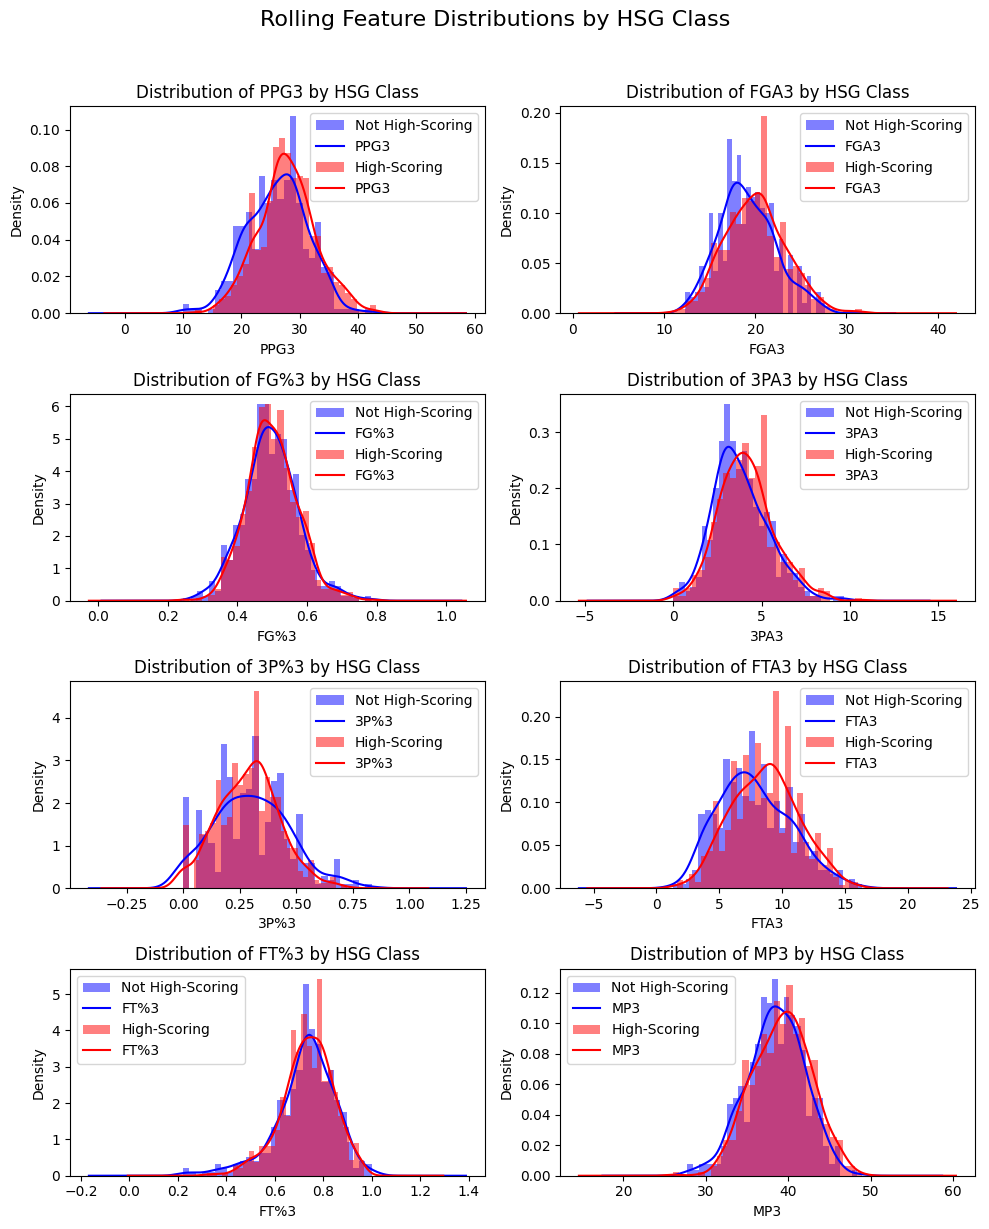

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

rolling_features = ['PPG3', 'FGA3', 'FG%3', '3PA3', '3P%3', 'FTA3', 'FT%3', 'MP3']

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()

for i, feature in enumerate(rolling_features):
    for hsg_val, label, color in [(0, 'Not High-Scoring', 'blue'), (1, 'High-Scoring', 'red')]:
        subset = train_df[train_df['HSG'] == hsg_val][feature]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color, density=True)
        subset.plot.kde(ax=axes[i], color=color)
    axes[i].set_title(f'Distribution of {feature} by HSG Class')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Rolling Feature Distributions by HSG Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

From these distributions, we observe that **volume-based features** (i.e., how much he shot or scored) such as `PPG3`, `FGA3`, `FTA3` show the clearest distinction between what games are high-scoring and not, with the high-scoring class consistently shifted toward higher values. **This suggests that LeBron's recent scoring output and shot volume are strong indicators of an upcoming high-scoring game.**

On the other hand, **efficiency-based features** (i.e., how well he shot, not how much he shot) like `FG%3`, `3P%3`, `FT%3` show significant overlap between both classes, which means that recent **shooting percentages are less likely to predict a high-scoring game**. `3PA3` and `MP3` fall in between, with slight separation but substantial overlap.

Overall, if LeBron been taking a lot of shots and scoring a lot lately, that's a stronger signal he'll hit 25+ points. But if he's been shooting at a high percentage lately, that doesn't really tell us much either way.

In [5]:
rolling_features = ['PPG3', 'FGA3', 'FG%3', '3PA3', '3P%3', 'FTA3', 'FT%3', 'MP3']

train_df.groupby('HSG')[rolling_features].mean().round(3)

,PPG3,FGA3,FG%3,3PA3,3P%3,FTA3,FT%3,MP3
HSG,,,,,,,,
0,26.121,19.136,0.496,3.799,0.302,7.791,0.726,38.468
1,27.788,20.036,0.501,4.135,0.289,8.645,0.736,39.266


Here we take a look of the mean of each rolling feature separated by the `HSG` class once again. From these values, we can see that the features where `HSG`=1 consistently shows **higher means** than `HSG`=0 are the **volume-based features** (`PPG3`, `FGA3`, `FTA3`) and `MP3`, though the difference in `MP3` is notably smaller than the others. In contrast, **efficiency-based features**  (`FG%3`, `FT%3`, and `3P%3`) show nearly **identical means** across both classes, reinforcing that shooting percentages **do little** to help predict whether a game will be high-scoring.

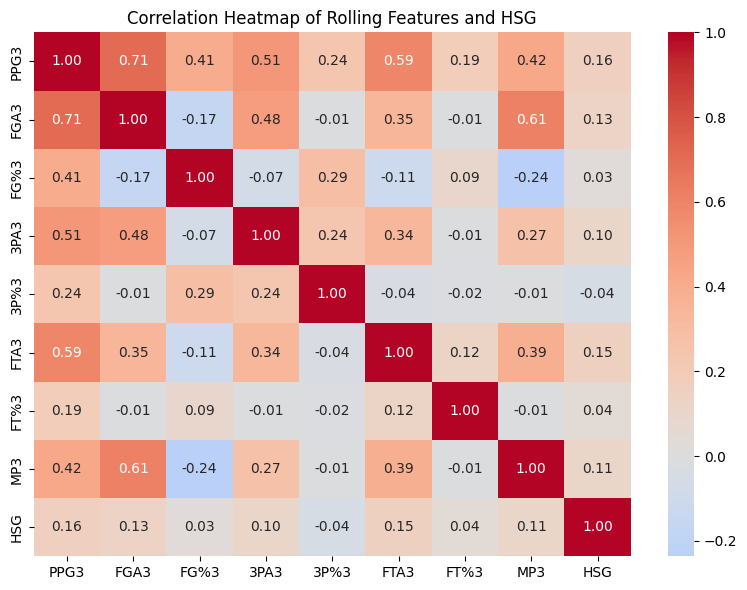

In [6]:
corr = train_df[['PPG3', 'FGA3', 'FG%3', '3PA3', '3P%3', 'FTA3', 'FT%3', 'MP3', 'HSG']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Rolling Features and HSG")
plt.tight_layout()
plt.show()

The heatmap above shows the correlation between each rolling feature and `HSG`. Looking at the `HSG` row, **all rolling features show relatively low correlations  with the target**, with `PPG3` (0.16) and `FTA3` (0.15) being the strongest. Efficiency-based features like `FG%3`, `FT%3`, and `3P%3` are near zero, confirming they have little to no relationship with `HSG`.

The heatmap also reveals that some features are correlated with each other, notably `PPG3` and `FGA3` (0.71) and `FGA3` and `MP3` (0.61), meaning they carry overlapping information. No single rolling feature strongly predicts `HSG` on its own, which tells us that the model will need to combine multiple features together to make accurate predictions.

### 2) Does home or away status have a meaningful effect on LeBron's likelihood of having a high-scoring game?

**Home/away status** `Home` is one of the simplest features in our dataset, yet its effect on scoring is not immediately obvious. Examining whether game location produces a consistent difference in HSG rates helps justify its inclusion as a feature in our models.

To answer the second research question, we compute the high-scoring game rate for home and away games separately and visualize the difference using a bar chart. The game counts are included to ensure the comparison is not skewed by unequal sample sizes.

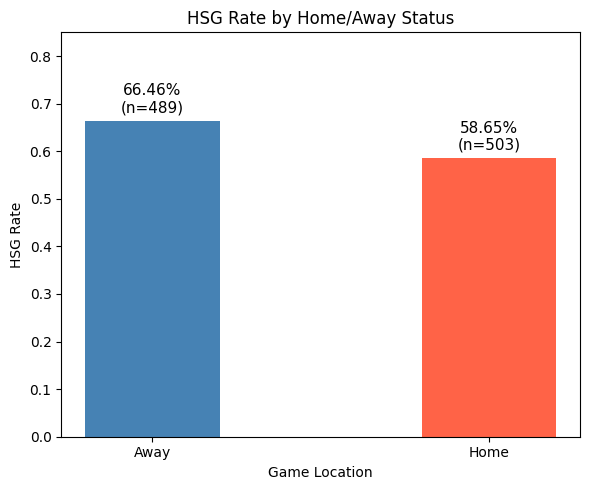

In [7]:
# Compute HSG rate and game counts by Home/Away
home_stats = train_df.groupby('Home')['HSG'].agg(['mean', 'count']).reset_index()
home_stats.columns = ['Home', 'HSG_Rate', 'Count']
home_stats['Label'] = home_stats['Home'].map({0: 'Away', 1: 'Home'})

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(home_stats['Label'], home_stats['HSG_Rate'], 
              color=['steelblue', 'tomato'], width=0.4)

# Annotate with HSG rate and game count
for bar, (_, row) in zip(bars, home_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{row['HSG_Rate']:.2%}\n(n={int(row['Count'])})",
            ha='center', va='bottom', fontsize=11)

ax.set_title('HSG Rate by Home/Away Status')
ax.set_xlabel('Game Location')
ax.set_ylabel('HSG Rate')
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.show()

The bar chart shows that LeBron has a higher high-scoring game rate in away games (66.46%) compared to home games (58.65%), which is counterintuitive as players  generally tend to perform better at home. The sample sizes are balanced (n=489 away, n=503 home), so this difference is not due to unequal game counts. This suggests that home/away status does carry some predictive signal for `HSG`, with away games being slightly more associated with high-scoring performances.

### 3) Does LeBron's age affect scoring consistency?

To answer this question, we group LeBron's games into age bins and compute the HSG rate for each group. Since the training set spans roughly 20 years of his career, we use 4 bins of equal width to balance both detail and reliability, and make sure each bin contains enough number of games to produce reliable rates while still capturing meaningful age trends.

/var/folders/gx/43tk3vn57cz_5l13tqj_53mr0000gn/T/ipykernel_14960/3996714600.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Age_Bin'] = pd.cut(train_df['Age'], bins=[18, 22, 26, 30, 34, 39])


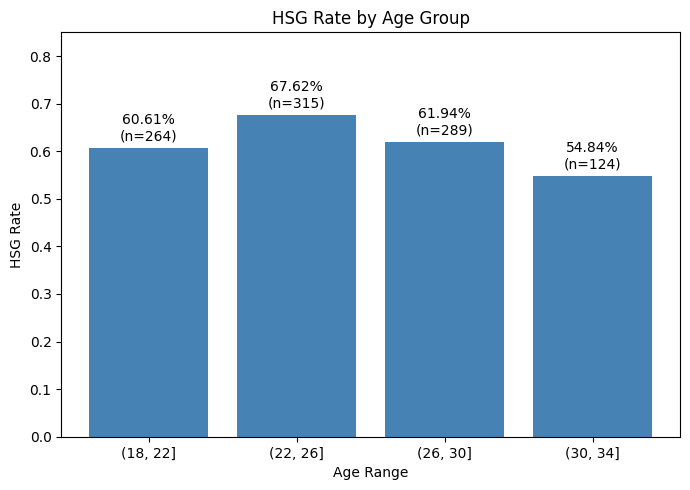

In [9]:
# Bin age into equal intervals
train_df['Age_Bin'] = pd.cut(train_df['Age'], bins=[18, 22, 26, 30, 34, 39])

age_stats = train_df.groupby('Age_Bin', observed=False)['HSG'].agg(['mean', 'count']).reset_index()
age_stats.columns = ['Age_Bin', 'HSG_Rate', 'Count']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(age_stats['Age_Bin'].astype(str), age_stats['HSG_Rate'], color='steelblue')

for bar, (_, row) in zip(bars, age_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{row['HSG_Rate']:.2%}\n(n={int(row['Count'])})",
            ha='center', va='bottom', fontsize=10)

ax.set_title('HSG Rate by Age Group')
ax.set_xlabel('Age Range')
ax.set_ylabel('HSG Rate')
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.show()

The bar chart above shows us that LeBron's high-scoring game rate is highest in the 22-26 age range (67.62%) and gradually goes down as he gets older, dropping to 54.84% in the 30-34 range. This shows a mild downward trend in scoring consistency with age, though the differences across bins are not dramatic. The 34-39 age group is absent from the training set as those games fall in the later portion of the dataset, which is reserved for validation and testing.

---
### 4) Feature Importance Analysis on `LJ_Dataset_DERIV`

In this section, we use a Random Forest classifier to compute feature importances on the derived dataset (`LJ_Dataset_DERIV.csv`), giving us a data-driven ranking of which features matter most for predicting whether LeBron has a high-scoring game (`HSG`).

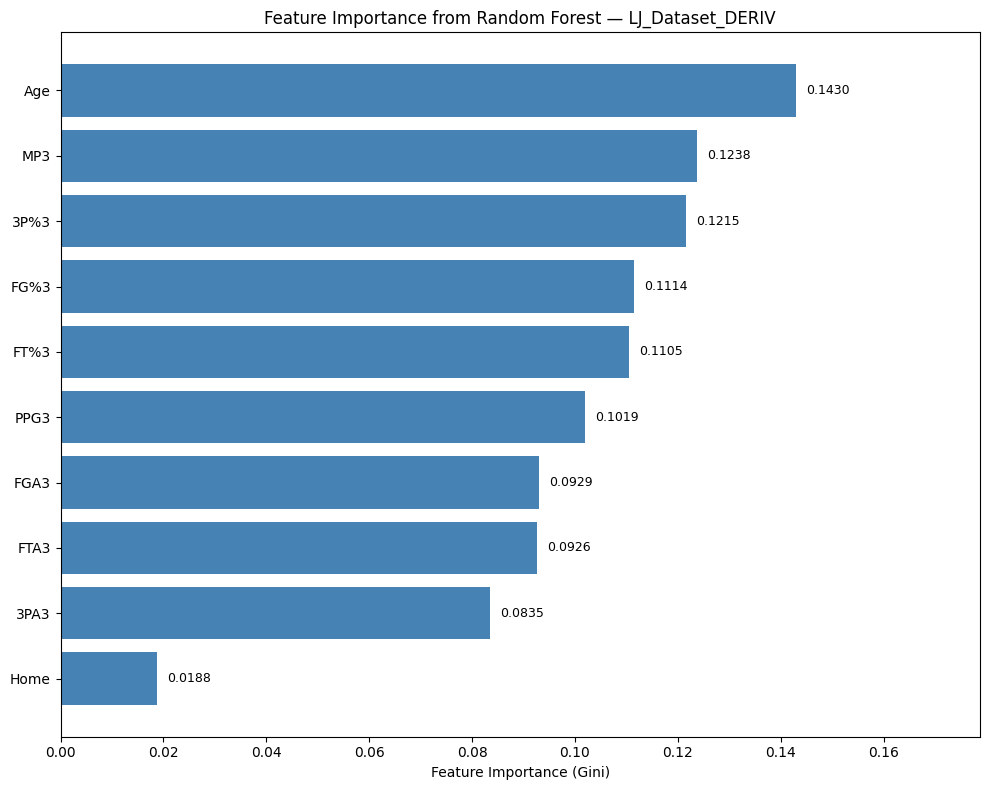


Feature Importance Ranking:
Age     0.142992
MP3     0.123778
3P%3    0.121525
FG%3    0.111434
FT%3    0.110499
PPG3    0.101905
FGA3    0.092946
FTA3    0.092636
3PA3    0.083490
Home    0.018795


In [11]:
# Train a Random Forest to get feature importances
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Extract and sort feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Plot feature importance (horizontal bar chart)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances.index, importances.values, color='steelblue')

# Annotate bars with importance values
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance from Random Forest — LJ_Dataset_DERIV')
ax.set_xlim(0, importances.max() * 1.25)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(importances.sort_values(ascending=False).to_string())

---

## Conclusions

Based on the exploratory data analysis conducted across the three research questions, 
we can draw the following conclusions:

1. **Rolling performance averages** show that volume-based features (`PPG3`, `FGA3`, `FTA3`) are the most informative for predicting `HSG`, as they show the clearest separation between classes. Efficiency-based features (`FG%3`, `FT%3`, `3P%3`) show little to no difference between classes and are unlikely to contribute much predictive value. Additionally, no single rolling feature strongly predicts `HSG` on its own, suggesting the model will need to combine multiple features.

2. **Home/away status** shows a noticeable difference in HSG rates, with LeBron scoring 25 or more points more often in away games (66.46%) than home games (58.65%). Despite being counterintuitive, the balanced sample sizes confirm this is a genuine pattern, making game location a useful feature for the model.

3. **Age** shows a slight downward trend in HSG rate as LeBron gets older, peaking at 67.62% in the 22-26 age range and declining to 54.84% in the 30-34 range. While the differences across age groups are not drastic, the pattern suggests that age carries some useful information for predicting scoring consistency.

Overall, the most promising features going into model training are `PPG3`, `FGA3`, `FTA3`, `Home`, and `Age` while efficiency-based rolling features may contribute less to model performance.